In [1]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import os,cv2
from scipy.optimize import fmin
from scipy.ndimage import affine_transform
import shutil
from scipy.io import readsav
import glob
from matplotlib.patches import Rectangle
from scipy.ndimage import zoom

In [2]:
file_list=glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\iris_l2_20240618_163141_3602506433_raster\*.fits')
rsm=fits.open(file_list[399])
rsm_1400=fits.open(r'C:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\iris_l2_20240618_163141_3602506433_SJI_1400_t000.fits')
solar_xy=readsav(r'C:\Learning\PHD1st\magnetic_reconnecion\data_process\solar_xy.sav')
print(solar_xy.keys())
solar_x=solar_xy['solar_x']
solar_y=solar_xy['solar_y']
all_sji_image=readsav(r'C:\Learning\PHD1st\magnetic_reconnecion\data_process\all_sji_image.sav')['matrix_struct']

dict_keys(['solar_x', 'solar_y'])


In [6]:
def gaussian(x,a,x0,sigma,noise):
    return a*np.exp(-(x-x0)**2/(2*sigma**2))+noise

c_kms = 299792.458
mu_ref = 1402.77
from matplotlib.ticker import MultipleLocator
file_list=glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\iris_l2_20240618_163141_3602506433_raster\*.fits')
rsm=fits.open(file_list[399])

doppler_vel=np.zeros((220))
sigma_vel=np.zeros((220))
wave_x=np.arange(1398.28,1398.28+164*0.0508,0.0508)
for i in range(220):
    #这个65是来自于取得yrange=[-352,-462]，查看solar_y发现第四列
    #也就是我们狭缝所在的位置，从65开始才是y在-462角秒及以上
    wave_y=rsm[4].data[4,65+i*3:68+i*3,:].mean(axis=0)

    x=wave_x[70:110]
    y=wave_y[70:110]
    #初始参数
    mu_initial=mu_ref
    a_initial=np.mean(y)
    noise_initial=0
    sigma_initial=0.05
    initial_guess=[a_initial,mu_initial,sigma_initial,noise_initial]
    popt,pcov=curve_fit(gaussian,x,y,p0=initial_guess)
    #获取参数
    a_fit,mu_fit,sigma_fit,noise_fit=popt
    sigma_fit=abs(sigma_fit)
    #计算多普勒速度
    doppler_vel[i]=(mu_fit-mu_ref)/mu_ref*c_kms
    sigma_vel[i]=sigma_fit/mu_ref*c_kms
    y_fit=gaussian(x,*popt)
    x_vel=(x-mu_ref)/mu_ref*c_kms
    plt.figure(figsize=(10, 6))
    plt.scatter(x_vel, y, label="point", color="red")  # 画原始数据点
    plt.plot(x_vel, y_fit, label="Gaussian", color="blue")  # 画拟合曲线
    plt.gca().xaxis.set_major_locator(MultipleLocator(20))  # 每 20 km/s 一个刻度
    plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5, label="Rest wavelength")  # 画参考竖线
    plt.title("Single Gaussian Fitting")
    plt.xlabel("Doppler velocity [km/s]")
    plt.ylabel("Intensity")
    plt.legend()
    plt.grid()
    plt.savefig(r'C:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\gaussian_fit_vel_403_211214\\'+str(i)+'.png')
    plt.close()

C:\Users\xiao\AppData\Local\Temp\ipykernel_34512\3588296266.py:26: OptimizeWarning: Covariance of the parameters could not be estimated
  popt,pcov=curve_fit(gaussian,x,y,p0=initial_guess)


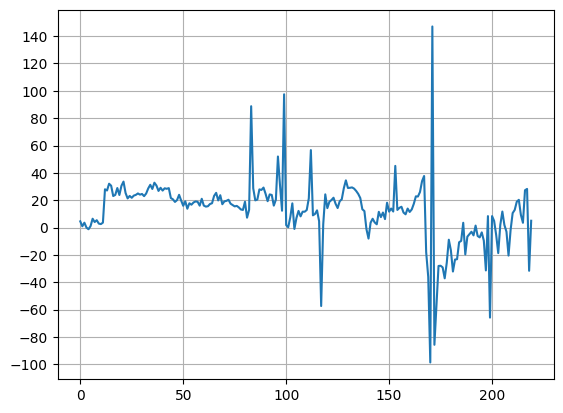

In [9]:
plt.plot(doppler_vel)
plt.gca().yaxis.set_major_locator(MultipleLocator(20))  # 每 20 km/s 一个刻度
plt.grid()

In [ ]:
data1 = all_sji_image[799][0]  # 第一组数据 (402x660)
data2 = doppler_vel  # 第二组数据 (长度220)
# 创建画布
fig, left_ax = plt.subplots(figsize=(5.5,8))  

# 左侧：imshow 画 402x660 矩阵（转换为角秒单位）
im = left_ax.imshow(data1, aspect='auto', cmap='irissji1400', origin='lower', 
                    vmin=0, vmax=23,extent=[0, 402*0.166, 0, 660*0.166])  # 关键修改：设置坐标范围为角秒)
left_ax.set_xlabel("X [arcsec]")  # 修改x轴标签
left_ax.set_ylabel("Y [arcsec]")  # 修改y轴标签

# 计算坐标偏移量（转换为角秒单位）
offset_pixel = (356.57 - 320)/0.166-10
offset_arcsec = offset_pixel * 0.166  # 像素转角秒
# 右侧：创建共享Y轴的新轴
right_ax = left_ax.twinx()
y_vals = np.linspace(0, 660*0.166, 220)  # 转换为角秒坐标

# 绘制调整后的data2（x坐标转换为角秒）
converted_data2 = data2 * 0.166 + offset_arcsec  # 关键修改：data2值转角秒
right_ax.plot(converted_data2, y_vals, color='cyan', linestyle='-', linewidth=1)
right_ax.set_title('2024-06-18 T21:09:27')
# 设置右侧次级x轴转换函数（处理角秒单位）
def data2_transform(x_arcsec):
    """将绘图坐标（角秒）转换回原始data2值"""
    return (x_arcsec - offset_arcsec) / 0.166

def inv_data2_transform(data2_val):
    """将原始data2值转换为绘图坐标（角秒）"""
    return data2_val * 0.166 + offset_arcsec

# 创建右侧x轴并设置标签
secax = right_ax.secondary_xaxis('top', functions=(data2_transform, inv_data2_transform))
secax.set_xlabel('Doppler velocity [km/s]')
#secax.axvline(0, color='gray', linestyle='--', alpha=0.5)
secax.minorticks_on()
zero_pos=inv_data2_transform(0)
right_ax.axvline(x=zero_pos,color='blue',linestyle='--',linewidth=0.8)
# 同步Y轴范围
right_ax.set_ylim(left_ax.get_ylim())

# 隐藏右侧多余的Y轴
#right_ax.yaxis.set_visible(False)

plt.show()


看一看

In [3]:
import numpy as np
print(3.4/np.sqrt(np.log(2))/np.sqrt(2))

2.8876941209792646


In [2]:
import numpy as np
print(np.log(10))

2.302585092994046
